LAB 7 24 March 2026

In [87]:
import pandas as pd
import numpy as np

data = pd.read_csv("Movies.csv")
dataframe = pd.DataFrame(data)
dataframe.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...


1. Find the percentage of Missing values in each column.

In [88]:
dataframe = dataframe.replace({None: np.nan})

In [89]:
miss_val = dataframe.isna().sum()
print(miss_val)

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


In [90]:
missing_percentage = (dataframe.isnull().sum() / len(dataframe)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)

print(missing_percentage)

director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
rating           0.089893
title            0.000000
show_id          0.000000
type             0.000000
release_year     0.000000
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64


2. For Columns, "country"and "rating", Replace the Missing value with Most probable value.

In [91]:
print(dataframe["country"].mode())
print(dataframe["rating"].mode())

0    United States
Name: country, dtype: str
0    TV-MA
Name: rating, dtype: str


In [92]:
dataframe.fillna({
    "country": dataframe["country"].mode()[0],
    "rating": dataframe["rating"].mode()[0]
}, inplace=True)

dataframe.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...


3. For "Date_Added" column, Replace NaN with any date in the "Release year" . if Release Year is also  NaN, then drop the row.

In [93]:
import random
from datetime import datetime, timedelta

to_drop = []

for i in dataframe.index:
    
    if pd.isna(dataframe.loc[i, "date_added"]) and pd.isna(dataframe.loc[i, "release_year"]):
        to_drop.append(i)

    elif pd.isna(dataframe.loc[i, "date_added"]) and pd.notna(dataframe.loc[i, "release_year"]):
        year = int(dataframe.loc[i, "release_year"])
        start = datetime(year, 1, 1)
        random_date = start + timedelta(days=random.randint(0, 364))
        dataframe.loc[i, "date_added"] = random_date.strftime("%Y-%m-%d")

dataframe = dataframe.drop(to_drop)

In [94]:
dataframe.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,United States,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


4. From Date_Added, Create new columns 'Year_Added' and'Month _Added'.

In [95]:
dataframe["date_added"] = pd.to_datetime(dataframe["date_added"], format="mixed")

dataframe["year_added"] = dataframe["date_added"].dt.year
dataframe["month_added"] = dataframe["date_added"].dt.month_name()

In [96]:
dataframe.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,August
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,December


5. Discretize Rating column into three values only ("Kid", "teen" , "Adult").

In [97]:
def categorize(x):
    if x in ["G", "TV-G", "TV-Y", "TV-Y7", "TV-Y7-FV", "NR", "UR"]:
        return "Kid"
    
    elif x in ["PG", "TV-PG", "PG-13", "TV-14"]:
        return "Teenager"
    
    else:
        return "Adult"

dataframe["rating"] = dataframe["rating"].apply(categorize)

In [98]:
dataframe.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,Adult,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,August
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,Adult,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,December
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,Adult,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,December
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,Teenager,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,November
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,Teenager,123 min,Dramas,A brilliant group of students become card-coun...,2020,January


6. Plot the number of movies in each rating group by each country.

In [99]:
from collections import Counter

country_counter = Counter()

for entry in dataframe["country"].dropna():
    for c in entry.split(","):
        c = c.strip()
        country_counter[c] += 1

top_countries = [c for c, _ in country_counter.most_common(30)]
print(len(country_counter))

118


In [101]:
import pandas as pd

result = {}

for country in top_countries:
    result[country] = {"Kid": 0, "Teenager": 0, "Adult": 0}

for _, row in dataframe.iterrows():
    if pd.isna(row["country"]):
        continue
    
    countries = row["country"].split(", ")
    
    for c in countries:
        if c in top_countries:
            result[c][row["rating"]] += 1

grouped = pd.DataFrame(result).T
print(grouped)

                Kid  Teenager  Adult
United States   558      1507   1738
India            41       698    251
United Kingdom   77       289    356
Canada          106       137    169
France           53        94    202
Japan            36       149    102
Spain            10        37    168
South Korea      28        94     90
Germany          20        72    107
Mexico           12        37    105
China            16        82     49
Australia        26        59     59
Egypt             0        78     32
Turkey            5        47     56
Hong Kong         2        49     51
Italy            14        30     46
Brazil           10        23     55
Taiwan            0        52     33
Belgium           6        17     62
Argentina         6        15     61
Indonesia         9        52     19
Philippines       4        44     30
Nigeria           2        43     31
Thailand          1        21     43
South Africa      1        22     31
Netherlands       7        14     24
C

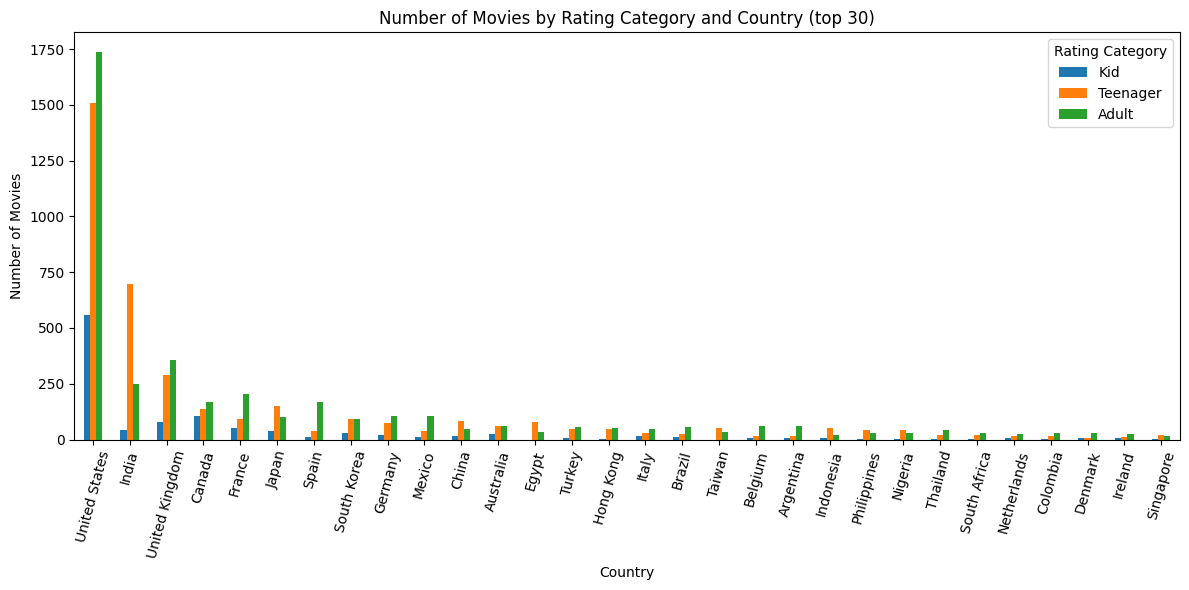

In [102]:
import matplotlib.pyplot as plt

grouped.plot(kind="bar", figsize=(12, 6))

plt.title("Number of Movies by Rating Category and Country (top 30)")
plt.xlabel("Country")
plt.ylabel("Number of Movies")
plt.xticks(rotation=75)
plt.legend(title="Rating Category")
plt.tight_layout()
plt.show()

7. Change the Listed-In column to single valued column by creating multiple columns foe each unique value in that column.

In [103]:
print(dataframe['listed_in'])

0       International TV Shows, TV Dramas, TV Sci-Fi &...
1                            Dramas, International Movies
2                     Horror Movies, International Movies
3       Action & Adventure, Independent Movies, Sci-Fi...
4                                                  Dramas
                              ...                        
7782                         Dramas, International Movies
7783       Dramas, International Movies, Music & Musicals
7784    Documentaries, International Movies, Music & M...
7785                   International TV Shows, Reality TV
7786                      Documentaries, Music & Musicals
Name: listed_in, Length: 7787, dtype: str


In [104]:
genres = set()

for entry in dataframe['listed_in']:
    val = entry.split(', ')
    for genre in val:
        genre.strip()
        genres.add(genre)

In [105]:
print(len(genres))
print((genres))

42
{'Anime Series', 'Korean TV Shows', 'Romantic TV Shows', 'Thrillers', 'Stand-Up Comedy', 'TV Thrillers', 'Classic & Cult TV', "Kids' TV", 'Comedies', 'Faith & Spirituality', 'Music & Musicals', 'Docuseries', 'TV Action & Adventure', 'TV Comedies', 'Movies', 'Sci-Fi & Fantasy', 'Reality TV', 'Independent Movies', 'International Movies', 'Teen TV Shows', 'Action & Adventure', 'Horror Movies', 'Dramas', 'TV Dramas', 'Documentaries', 'TV Shows', 'Crime TV Shows', 'British TV Shows', 'TV Horror', 'TV Sci-Fi & Fantasy', 'International TV Shows', 'Romantic Movies', 'LGBTQ Movies', 'TV Mysteries', 'Sports Movies', 'Spanish-Language TV Shows', 'Cult Movies', 'Anime Features', 'Classic Movies', 'Children & Family Movies', 'Science & Nature TV', 'Stand-Up Comedy & Talk Shows'}


In [106]:
for genre in genres:
    dataframe[genre] = 0

In [107]:
for idx, entry in dataframe['listed_in'].items():
    movie_genres = entry.split(', ')
    for genre in movie_genres:
        genre.strip()
        if genre in genres: 
            dataframe.at[idx, genre] = 1

In [108]:
print(dataframe.iloc[0])
print(dataframe.loc[0, 'listed_in'])

show_id                                                                        s1
type                                                                      TV Show
title                                                                          3%
director                                                                      NaN
cast                            João Miguel, Bianca Comparato, Michel Gomes, R...
country                                                                    Brazil
date_added                                                    2020-08-14 00:00:00
release_year                                                                 2020
rating                                                                      Adult
duration                                                                4 Seasons
listed_in                       International TV Shows, TV Dramas, TV Sci-Fi &...
description                     In a future where the elite inhabit an island ...
year_added      

In [109]:
dataframe = dataframe.drop('listed_in', axis=1)

7. Drop all the columns with large number of distinct values and label encode rest of the columns.

In [110]:
for col in dataframe.columns:
    print(col,"-----", dataframe[col].nunique())

show_id ----- 7787
type ----- 2
title ----- 7787
director ----- 4049
cast ----- 6831
country ----- 681
date_added ----- 1521
release_year ----- 73
rating ----- 3
duration ----- 216
description ----- 7769
year_added ----- 15
month_added ----- 12
Anime Series ----- 2
Korean TV Shows ----- 2
Romantic TV Shows ----- 2
Thrillers ----- 2
Stand-Up Comedy ----- 2
TV Thrillers ----- 2
Classic & Cult TV ----- 2
Kids' TV ----- 2
Comedies ----- 2
Faith & Spirituality ----- 2
Music & Musicals ----- 2
Docuseries ----- 2
TV Action & Adventure ----- 2
TV Comedies ----- 2
Movies ----- 2
Sci-Fi & Fantasy ----- 2
Reality TV ----- 2
Independent Movies ----- 2
International Movies ----- 2
Teen TV Shows ----- 2
Action & Adventure ----- 2
Horror Movies ----- 2
Dramas ----- 2
TV Dramas ----- 2
Documentaries ----- 2
TV Shows ----- 2
Crime TV Shows ----- 2
British TV Shows ----- 2
TV Horror ----- 2
TV Sci-Fi & Fantasy ----- 2
International TV Shows ----- 2
Romantic Movies ----- 2
LGBTQ Movies ----- 2
TV Mysteri

In [111]:
high_card_cols = [col for col in dataframe.columns if dataframe[col].nunique() > 500]

dataframe = dataframe.drop(high_card_cols, axis=1)
print(dataframe.columns)

Index(['type', 'release_year', 'rating', 'duration', 'year_added',
       'month_added', 'Anime Series', 'Korean TV Shows', 'Romantic TV Shows',
       'Thrillers', 'Stand-Up Comedy', 'TV Thrillers', 'Classic & Cult TV',
       'Kids' TV', 'Comedies', 'Faith & Spirituality', 'Music & Musicals',
       'Docuseries', 'TV Action & Adventure', 'TV Comedies', 'Movies',
       'Sci-Fi & Fantasy', 'Reality TV', 'Independent Movies',
       'International Movies', 'Teen TV Shows', 'Action & Adventure',
       'Horror Movies', 'Dramas', 'TV Dramas', 'Documentaries', 'TV Shows',
       'Crime TV Shows', 'British TV Shows', 'TV Horror',
       'TV Sci-Fi & Fantasy', 'International TV Shows', 'Romantic Movies',
       'LGBTQ Movies', 'TV Mysteries', 'Sports Movies',
       'Spanish-Language TV Shows', 'Cult Movies', 'Anime Features',
       'Classic Movies', 'Children & Family Movies', 'Science & Nature TV',
       'Stand-Up Comedy & Talk Shows'],
      dtype='str')


In [112]:
for col in dataframe:
    dataframe[col] = dataframe[col].astype('category').cat.codes

dataframe.head()

,type,release_year,rating,duration,year_added,month_added,Anime Series,Korean TV Shows,Romantic TV Shows,Thrillers,...,LGBTQ Movies,TV Mysteries,Sports Movies,Spanish-Language TV Shows,Cult Movies,Anime Features,Classic Movies,Children & Family Movies,Science & Nature TV,Stand-Up Comedy & Talk Shows
0,1,71,0,147,13,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,67,0,209,9,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,62,0,190,11,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,60,2,194,10,9,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,59,2,30,13,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


8. perform correlation analysis on the rest of the labels.

In [113]:
corr_matrix = dataframe.corr()
print(corr_matrix)

                                  type  release_year    rating  duration  \
type                          1.000000      0.175275 -0.002952 -0.387710   
release_year                  0.175275      1.000000 -0.155640 -0.002888   
rating                       -0.002952     -0.155640  1.000000 -0.055438   
duration                     -0.387710     -0.002888 -0.055438  1.000000   
year_added                    0.005654      0.102605 -0.014822 -0.077162   
month_added                  -0.004410     -0.003537  0.007674 -0.001846   
Anime Series                  0.207909      0.004480  0.026161 -0.073483   
Korean TV Shows               0.209337      0.041281  0.031986 -0.117517   
Romantic TV Shows             0.315710      0.040707  0.072924 -0.175516   
Thrillers                    -0.173675      0.019847 -0.099543  0.043610   
Stand-Up Comedy              -0.140613      0.035660 -0.166037  0.199939   
TV Thrillers                  0.120077      0.030719 -0.032307 -0.025750   
Classic & Cu

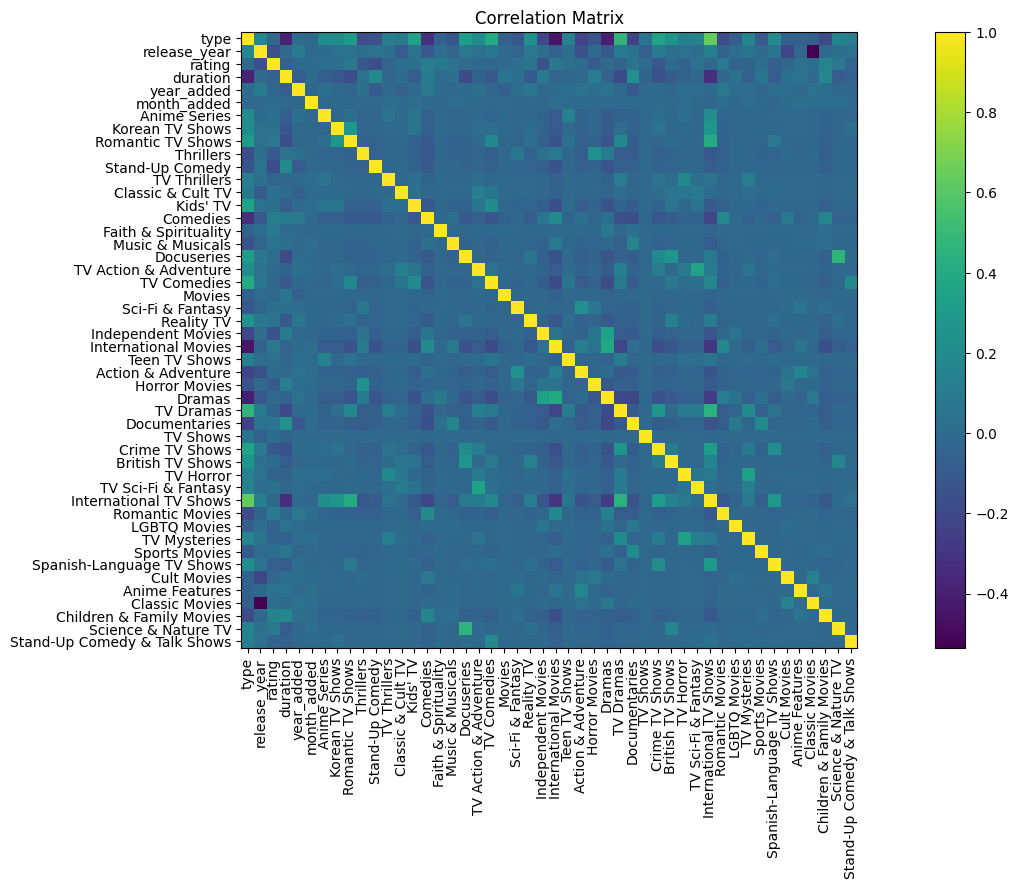

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.show()

In [115]:
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
print(corr_pairs)

type                  type                    1.000000
Stand-Up Comedy       Stand-Up Comedy         1.000000
TV Thrillers          TV Thrillers            1.000000
Thrillers             Thrillers               1.000000
Classic Movies        Classic Movies          1.000000
                                                ...   
Dramas                type                   -0.407620
type                  International Movies   -0.451845
International Movies  type                   -0.451845
Classic Movies        release_year           -0.535510
release_year          Classic Movies         -0.535510
Length: 2304, dtype: float64
